## Solar Power Generation - Regression Project

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 1 . Read the data

In [3]:
df = pd.read_csv('/content/solarpowergeneration.csv')
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


#### Step 2. Examine the data

In [4]:
df.shape

(2920, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [6]:
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# descriptive statistics
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [9]:
# Check for missing values
df.isna().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),1
average-pressure-(period),0
power-generated,0


In [10]:
# visualize null values

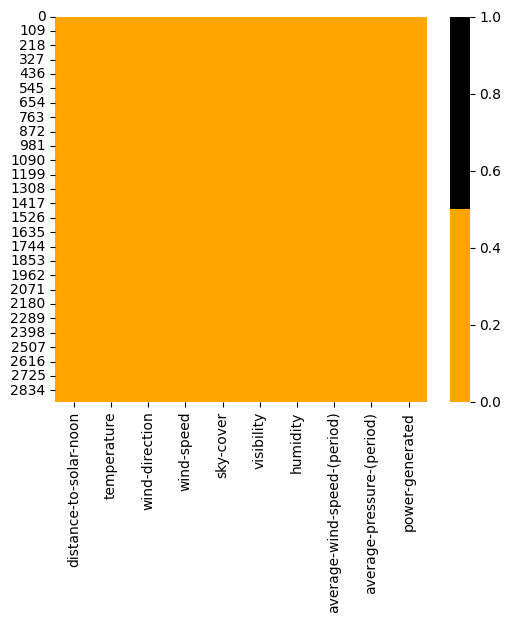

In [11]:
plt.figure(figsize=(6,5))
cols=['orange','black']
sns.heatmap(df.isnull(),cmap=cols)
plt.show()

In [12]:
df['average-wind-speed-(period)'].fillna(df['average-wind-speed-(period)'].median(), inplace=True)


In [13]:
# Check for missing values and handling it
df.isna().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),0
average-pressure-(period),0
power-generated,0


#### Step 3. Visualization of data

In [14]:
target = 'power-generated'

### Correlation Matrix

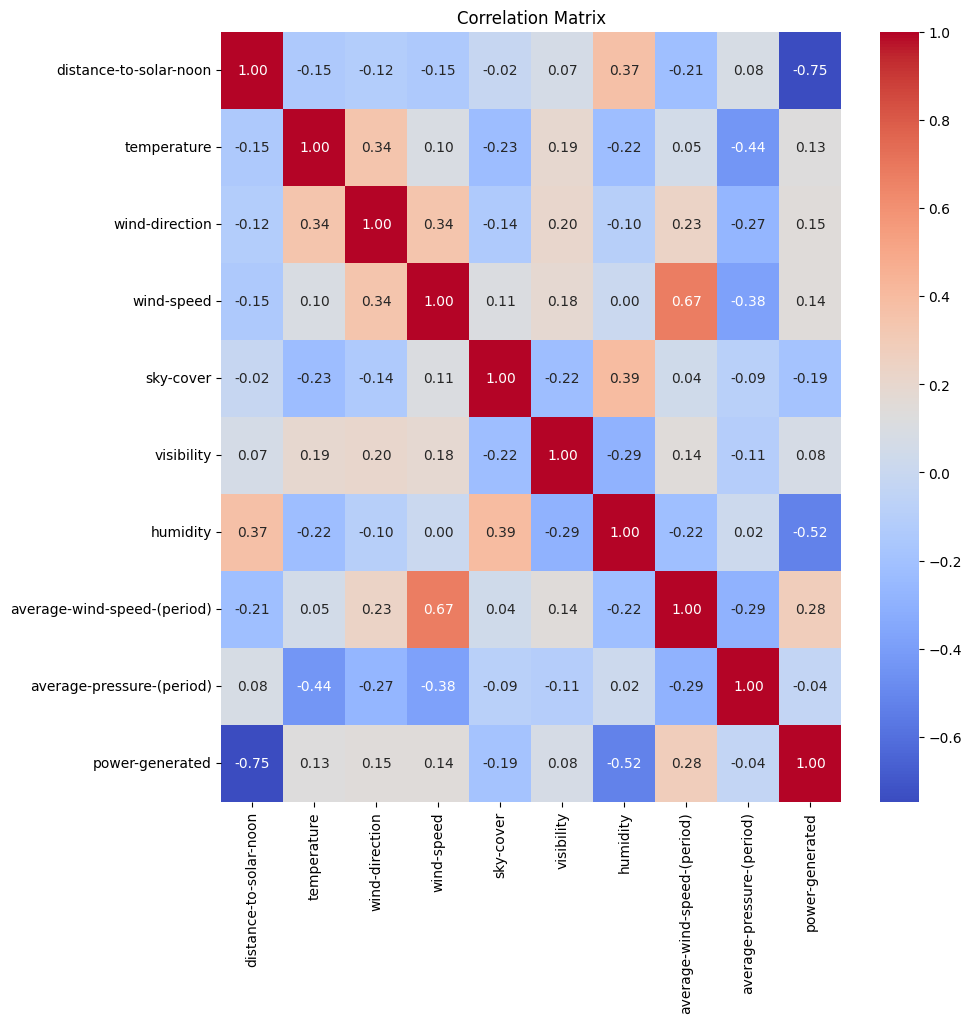


Correlation with Target Variable:
 power-generated                1.000000
average-wind-speed-(period)    0.278188
wind-direction                 0.146788
wind-speed                     0.142641
temperature                    0.132193
visibility                     0.076536
average-pressure-(period)     -0.036771
sky-cover                     -0.187236
humidity                      -0.522545
distance-to-solar-noon        -0.746681
Name: power-generated, dtype: float64


In [15]:
# Correlation matrix heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

corr_target = df.corr()[target].sort_values(ascending=False)
print("\nCorrelation with Target Variable:\n", corr_target)

In [16]:
# Feature Insights Summary

print("\n EDA Summary:")
print(f"Total Records after cleaning: {df.shape[0]}")
print('--------------------------------------------------------------------------------')
print(f"Strongest predictors (corr > 0.5):\n{corr_target[corr_target.abs() > 0.5]}")


 EDA Summary:
Total Records after cleaning: 2920
--------------------------------------------------------------------------------
Strongest predictors (corr > 0.5):
power-generated           1.000000
humidity                 -0.522545
distance-to-solar-noon   -0.746681
Name: power-generated, dtype: float64



 Top 5 Most Correlated Features with Power Generated:

average-wind-speed-(period)    0.278188
wind-direction                 0.146788
wind-speed                     0.142641
temperature                    0.132193
visibility                     0.076536
Name: power-generated, dtype: float64


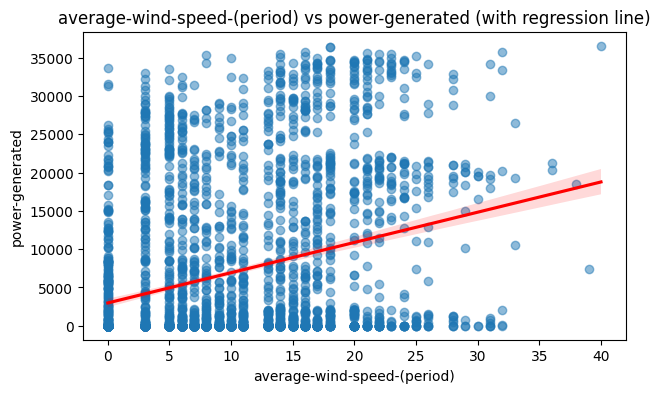

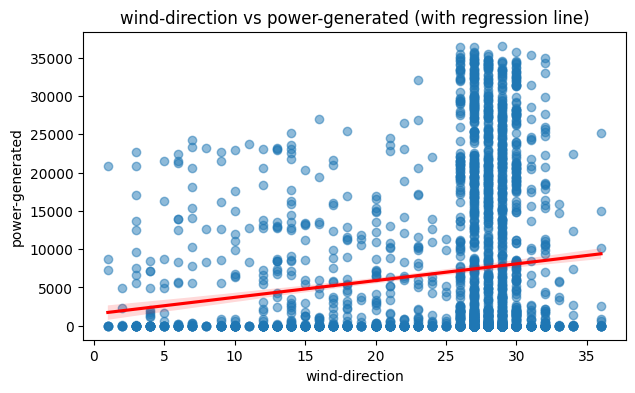

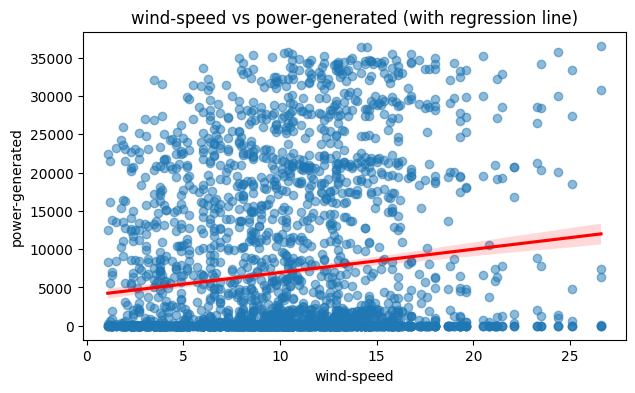

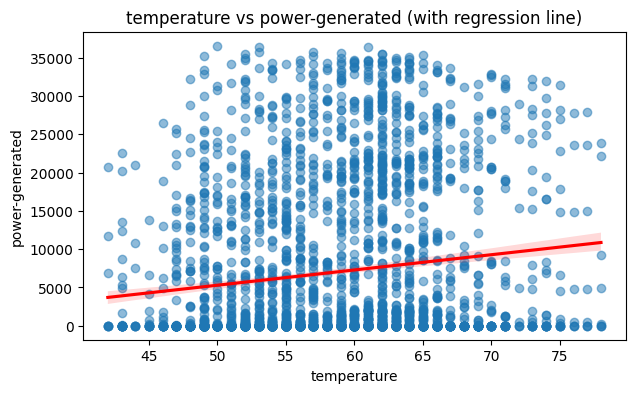

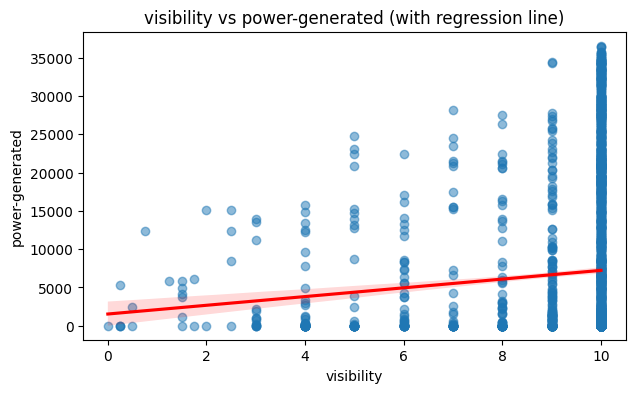

In [17]:
# Relationship between environmental factors and power_generated

important_features = corr_target[1:6].index  # top 5 correlated (excluding target itself)

print("\n Top 5 Most Correlated Features with Power Generated:\n")
print(corr_target[1:6])

for feature in important_features:
    plt.figure(figsize=(7, 4))
    sns.regplot(x=df[feature], y=df[target], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f"{feature} vs {target} (with regression line)")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()

In [18]:
# Multicollinearity (highly correlated input features)
corr_matrix = df.corr()

In [19]:
# Selecting upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [20]:
high_corr_features = [column for column in upper.columns if any(upper[column].abs() > 0.8)]
print("\n Highly correlated features (corr > 0.8):", high_corr_features)


 Highly correlated features (corr > 0.8): []


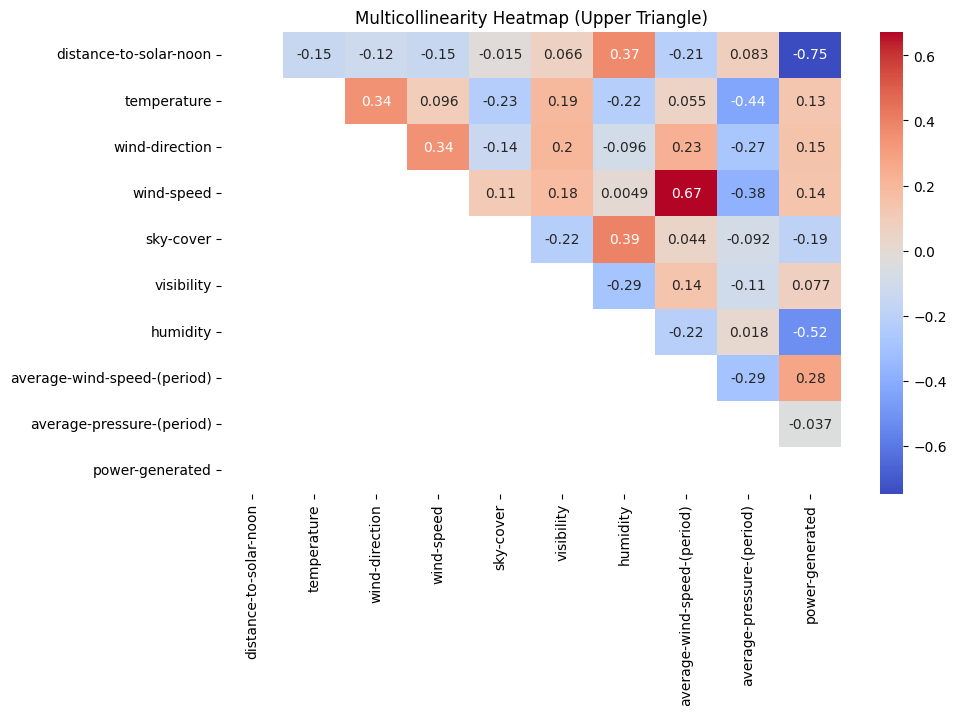

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(upper, annot=True, cmap='coolwarm')
plt.title("Multicollinearity Heatmap (Upper Triangle)")
plt.show()

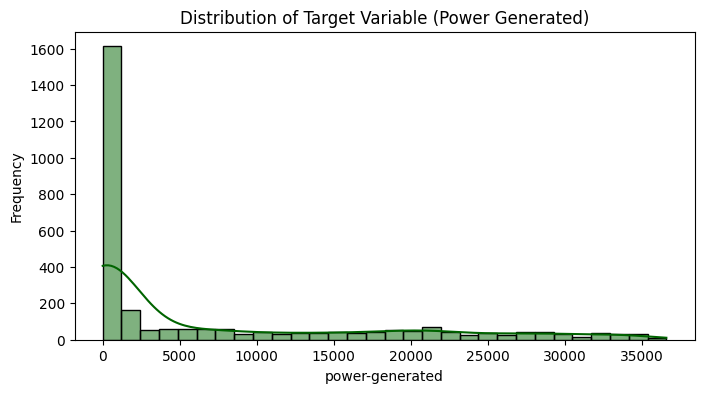


Target Skewness: 1.31
Target is highly skewed — consider log transformation during modeling.


In [22]:
# Distribution of Target Variable

plt.figure(figsize=(8, 4))
sns.histplot(df[target], kde=True, color='darkgreen', bins=30)
plt.title("Distribution of Target Variable (Power Generated)")
plt.xlabel(target)
plt.ylabel("Frequency")
plt.show()

print(f"\nTarget Skewness: {df[target].skew():.2f}")
if abs(df[target].skew()) > 1:
    print("Target is highly skewed — consider log transformation during modeling.")
else:
    print("Target is approximately symmetric — suitable for regression.")

In [23]:
df.columns.tolist()

['distance-to-solar-noon',
 'temperature',
 'wind-direction',
 'wind-speed',
 'sky-cover',
 'visibility',
 'humidity',
 'average-wind-speed-(period)',
 'average-pressure-(period)',
 'power-generated']

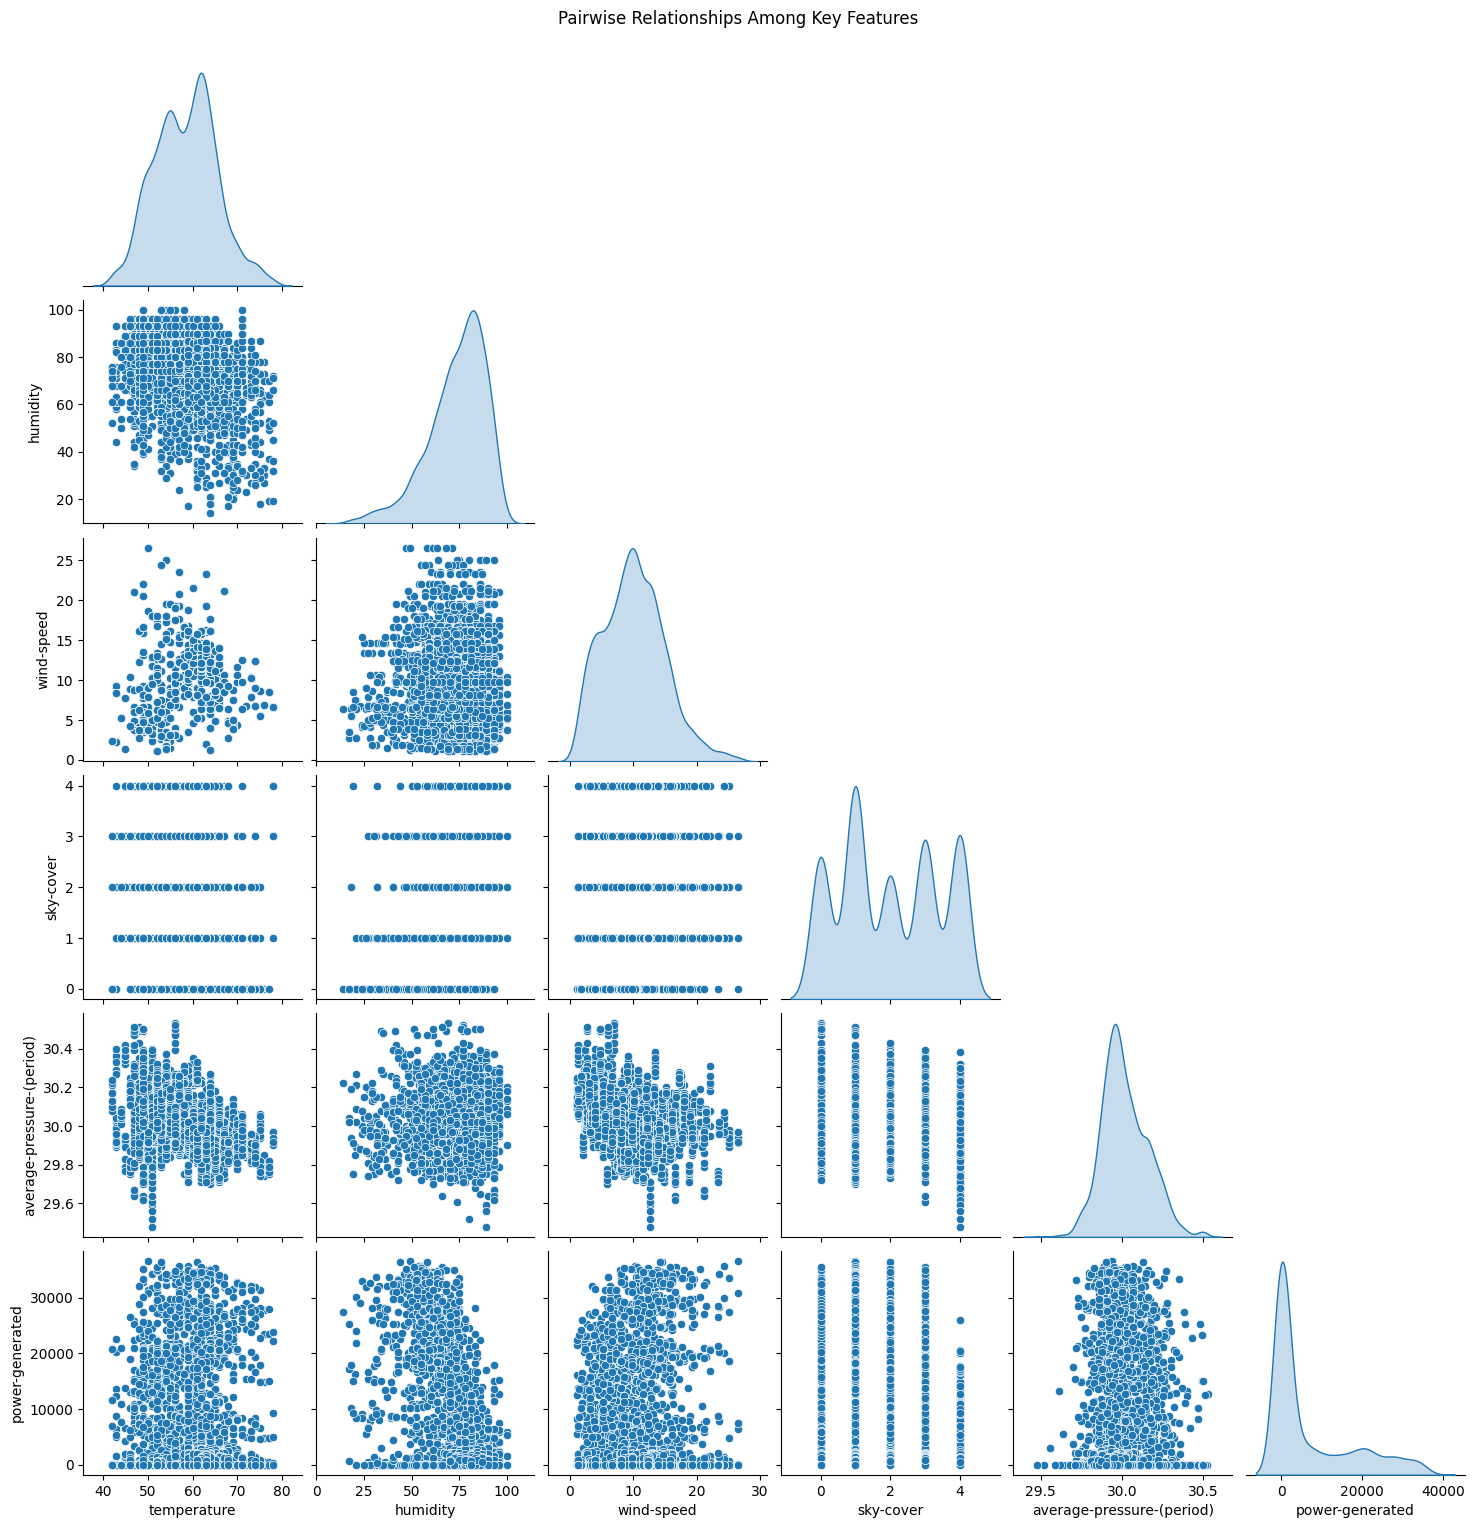

In [24]:
# Pairwise Relationships (Selected Important Features)
selected_cols = ['temperature', 'humidity', 'wind-speed', 'sky-cover', 'average-pressure-(period)', target]

sns.pairplot(df[selected_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships Among Key Features", y=1.02)
plt.show()

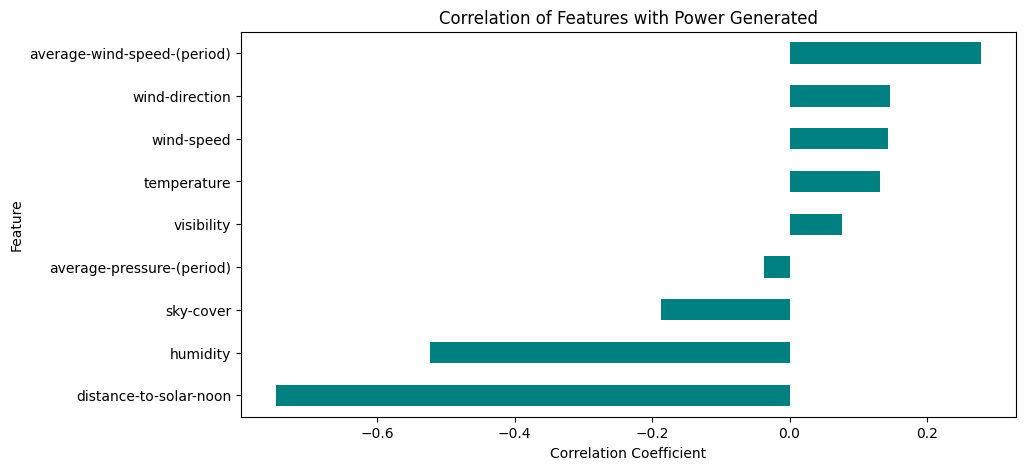

In [25]:
# Feature-to-Target Correlation Bar Chart

plt.figure(figsize=(10,5))
corr_target.drop(target).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Correlation of Features with Power Generated")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

In [26]:
# Key Insights Summary
print("KEY INSIGHTS SUMMARY \n")

print("Strong positive correlation features:")
print(corr_target[corr_target > 0.5])

print("\n Strong negative correlation features:")
print(corr_target[corr_target < -0.3])

print("\n Variables with high multicollinearity (redundant):", high_corr_features)

print("\n Target variable skewness:", round(df[target].skew(), 2))
print("    (If > 1 or < -1, consider transformation.)")



KEY INSIGHTS SUMMARY 

Strong positive correlation features:
power-generated    1.0
Name: power-generated, dtype: float64

 Strong negative correlation features:
humidity                 -0.522545
distance-to-solar-noon   -0.746681
Name: power-generated, dtype: float64

 Variables with high multicollinearity (redundant): []

 Target variable skewness: 1.31
    (If > 1 or < -1, consider transformation.)


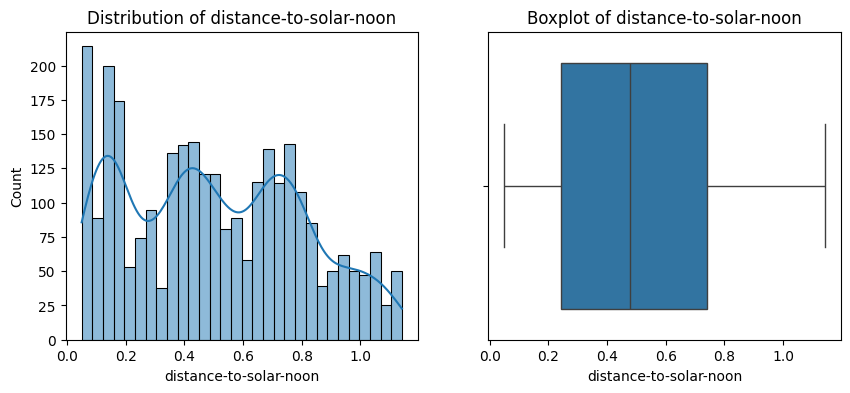

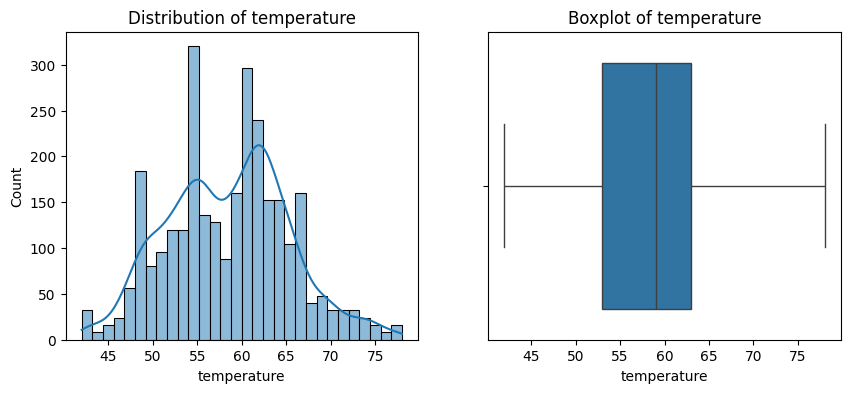

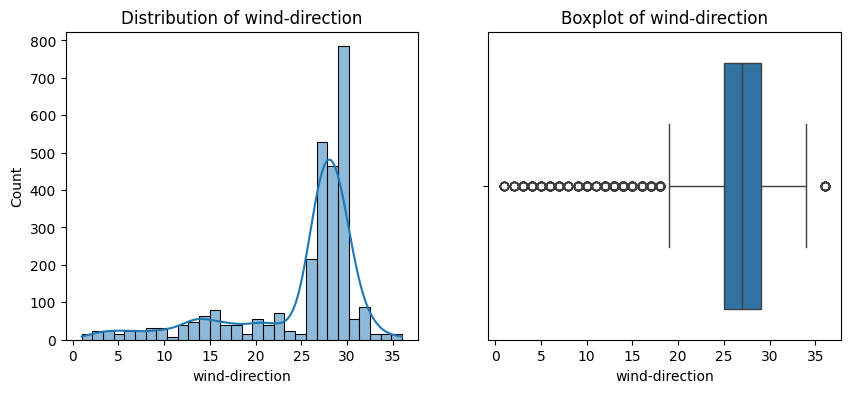

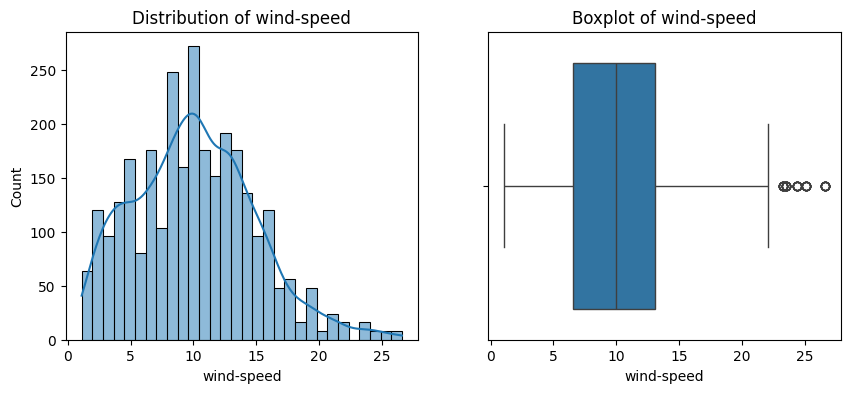

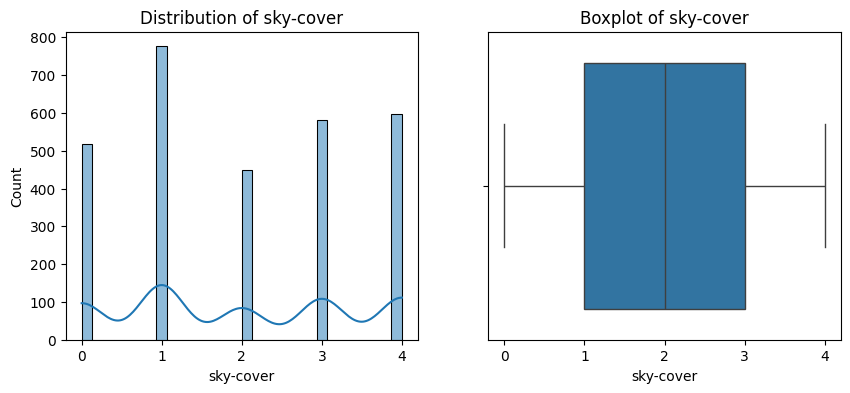

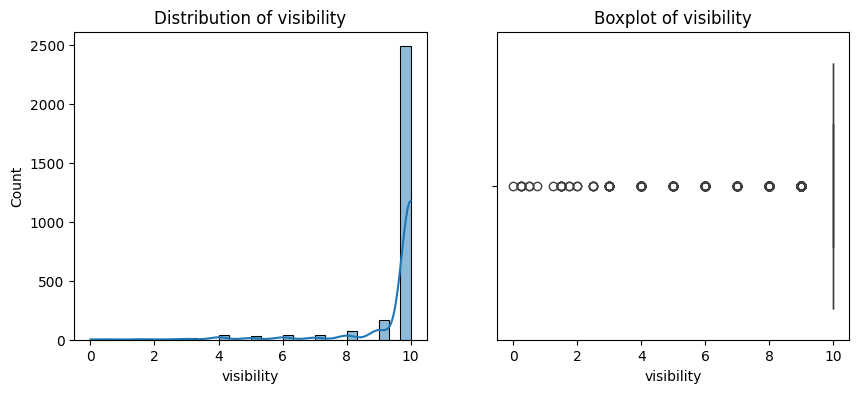

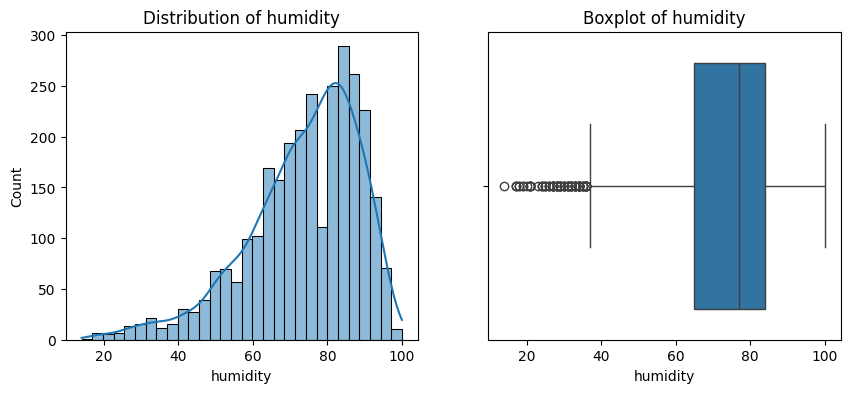

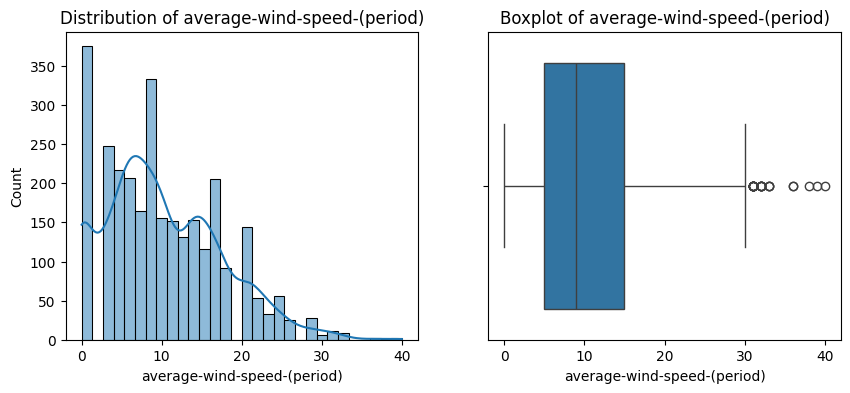

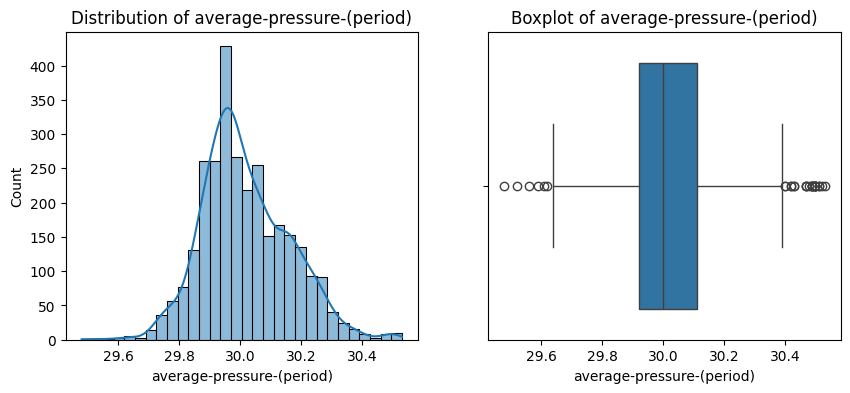

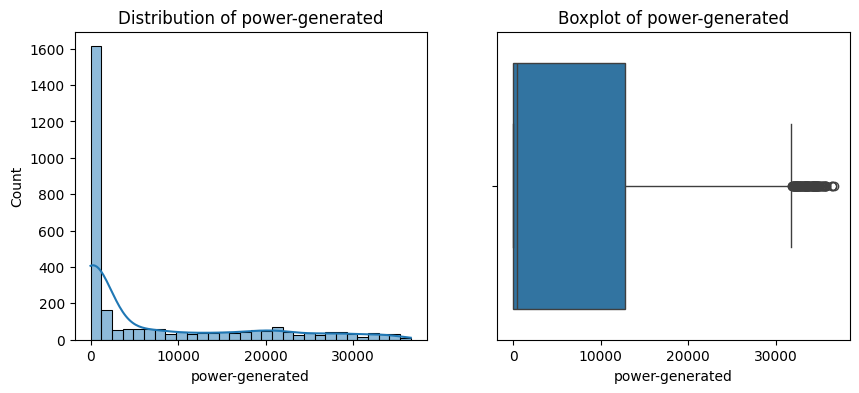

In [27]:
#  Univariate Analysis

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

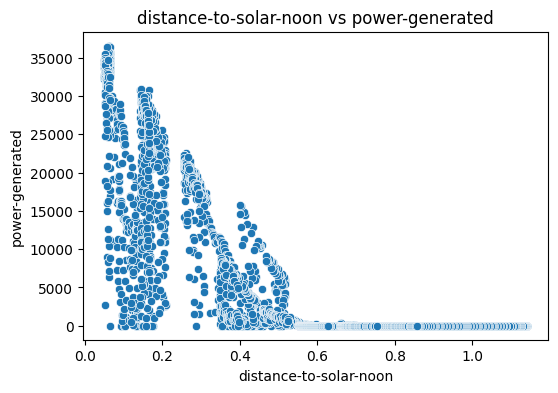

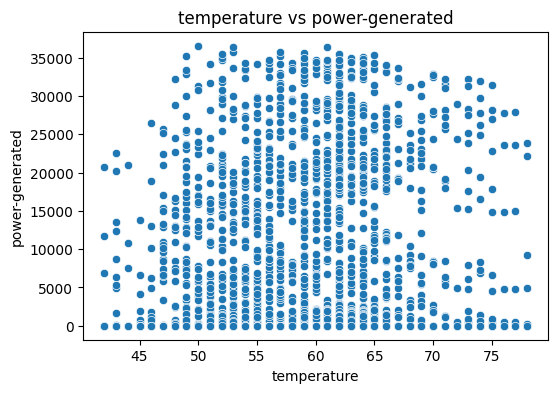

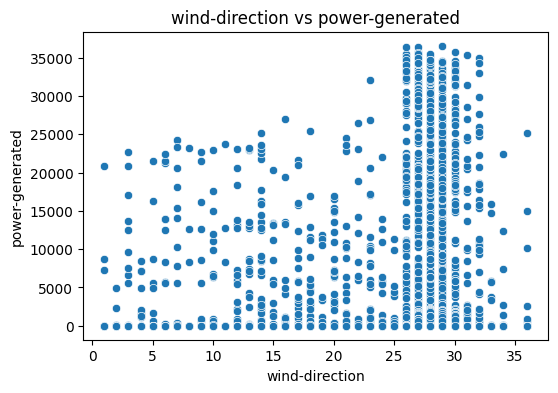

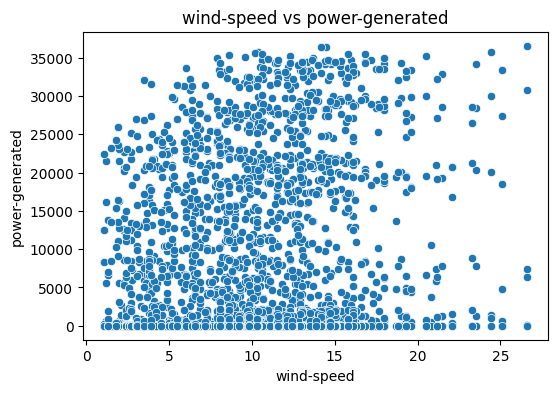

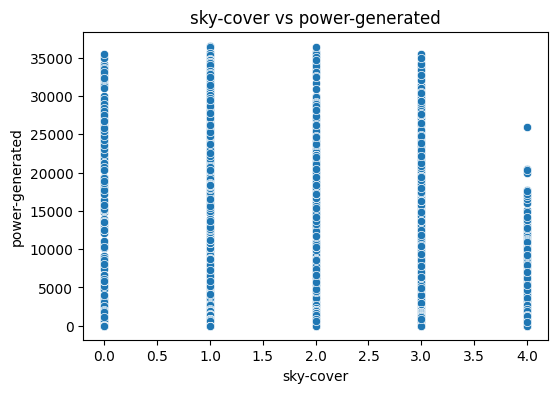

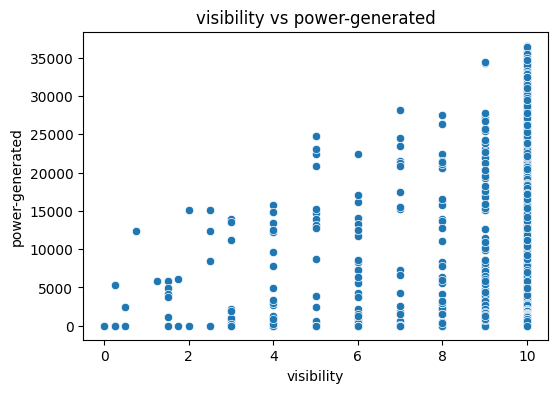

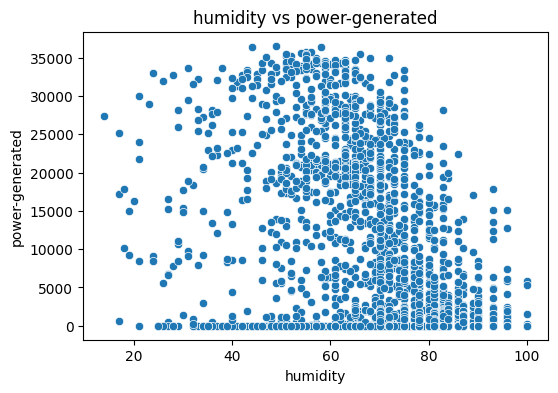

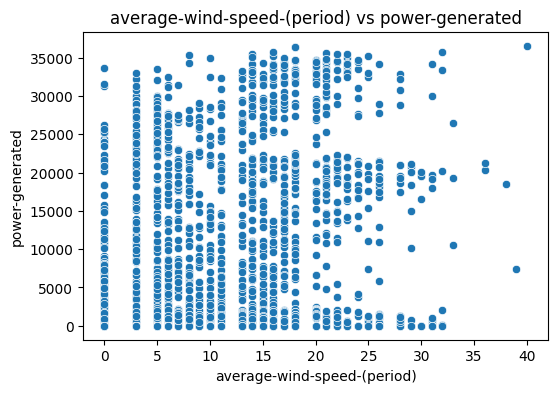

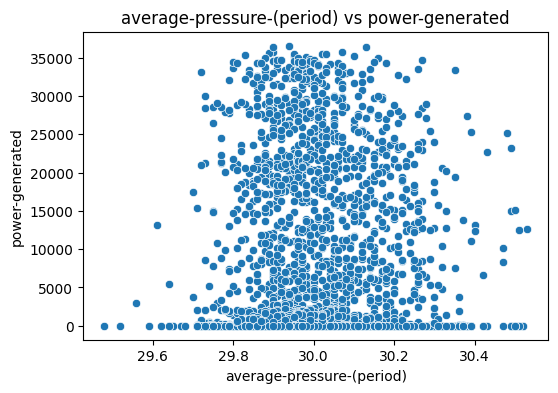

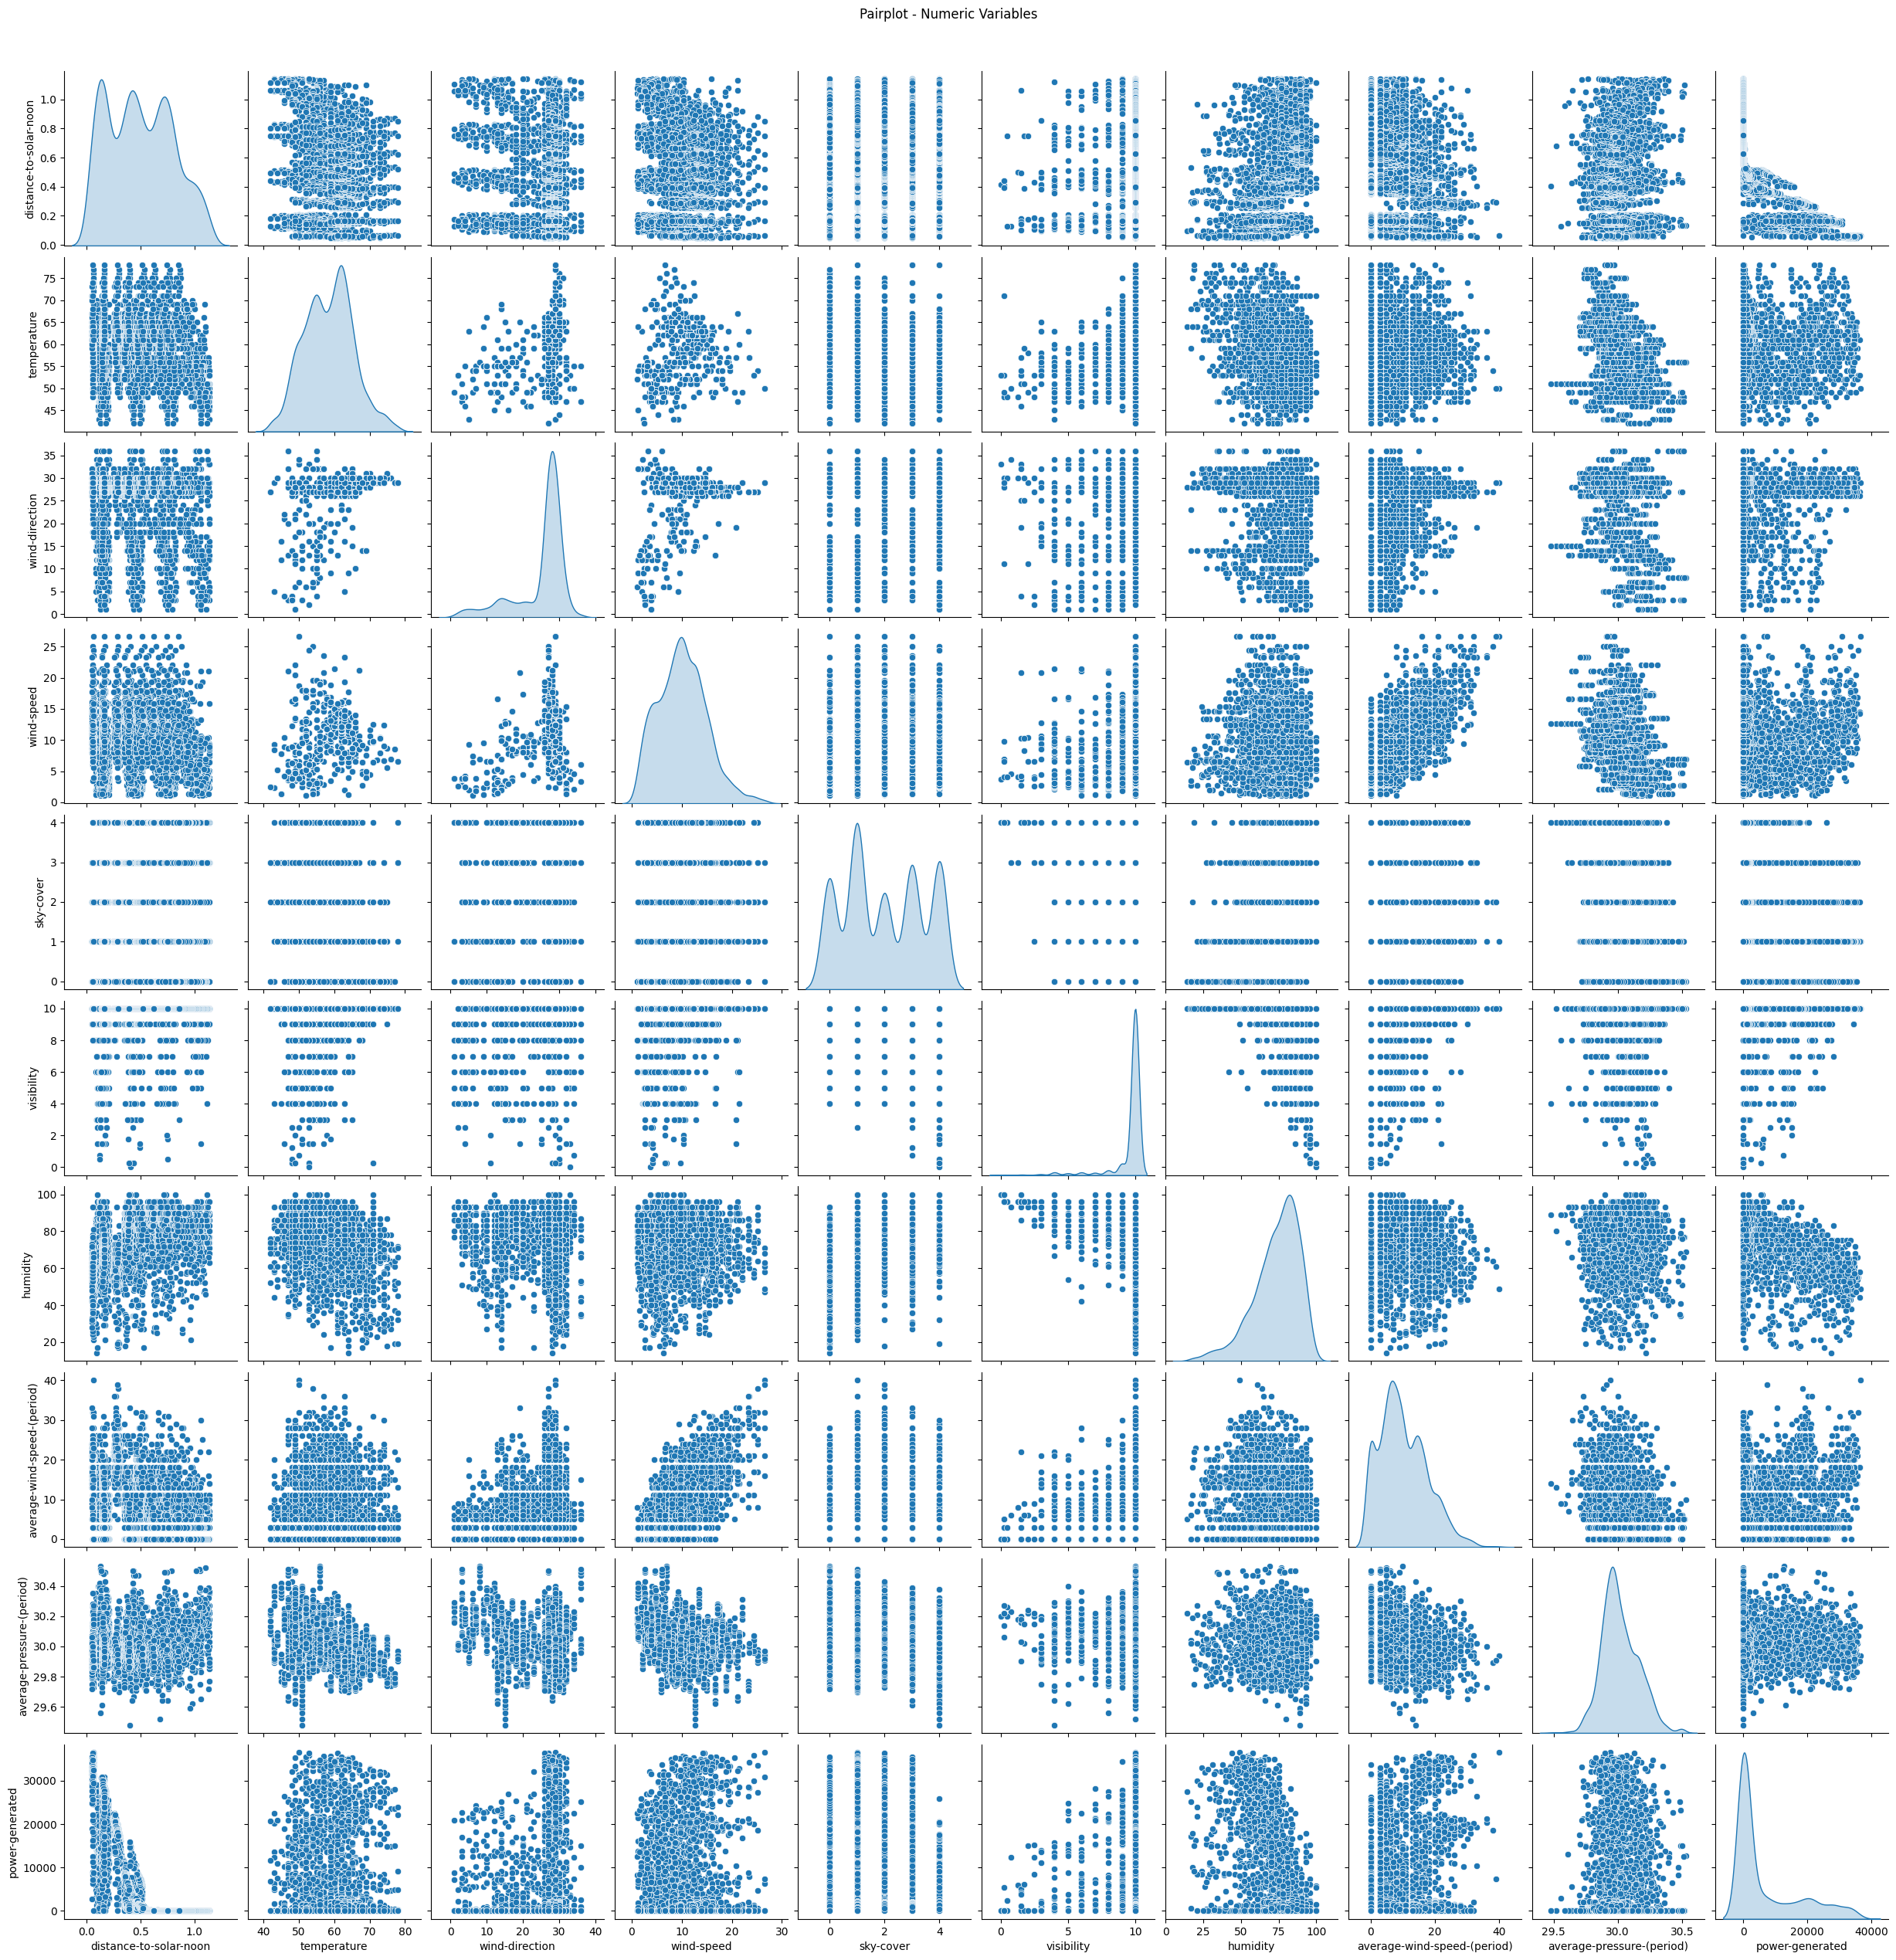

In [28]:
# Bivariate Analysis

target = 'power-generated'

for col in num_cols:
    if col != target:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

# Pairplot for quick relationship check
sns.pairplot(df[num_cols], diag_kind="kde")
plt.suptitle("Pairplot - Numeric Variables", y=1.02)
plt.show()

#### Step 4. Outliers Detection using IQR Method

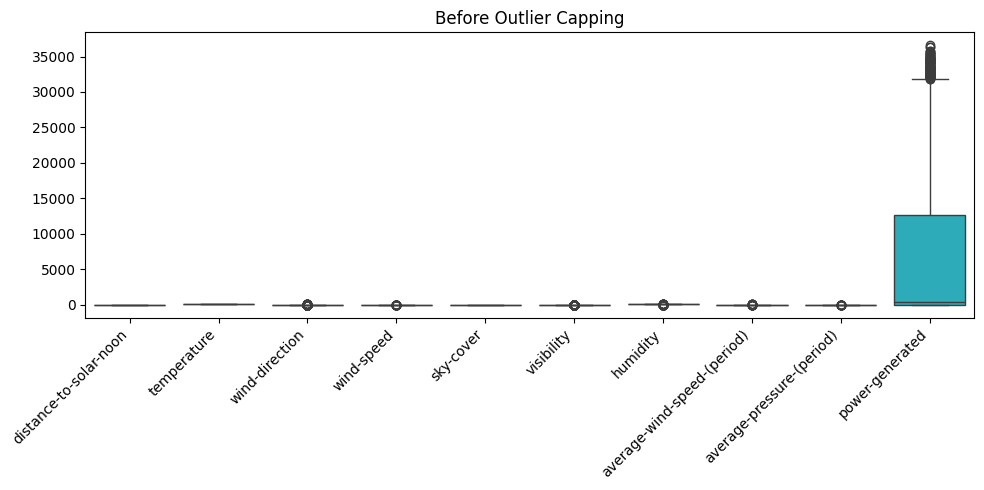

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.title("Before Outlier Capping")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
data = df.copy()


In [31]:
for col in data.select_dtypes(include=[np.number]).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower, upper)  # cap outliers


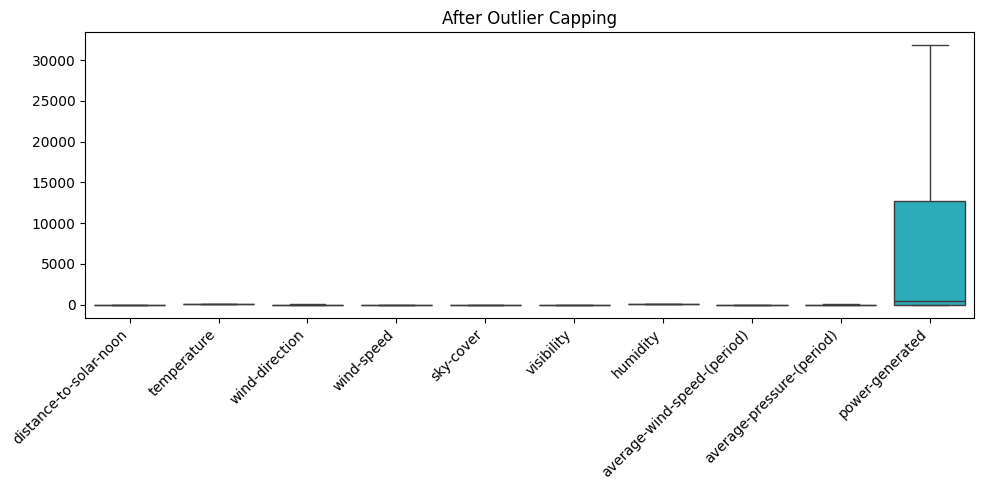

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data)
plt.title("After Outlier Capping")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
print("Outliers capped successfully!")


Outliers capped successfully!


In [34]:
data

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75.0,8.0,29.82,0.0
1,0.628535,69,28,7.5,0,10.0,77.0,5.0,29.85,0.0
2,0.397172,69,28,7.5,0,10.0,70.0,0.0,29.89,5418.0
3,0.165810,69,28,7.5,0,10.0,36.5,0.0,29.91,25477.0
4,0.065553,69,28,7.5,0,10.0,36.5,3.0,29.89,30069.0
...,...,...,...,...,...,...,...,...,...,...
2915,0.166453,63,27,13.9,4,10.0,75.0,10.0,29.93,6995.0
2916,0.064020,63,27,13.9,1,10.0,66.0,15.0,29.91,29490.0
2917,0.294494,63,27,13.9,2,10.0,68.0,21.0,29.88,17257.0
2918,0.524968,63,27,13.9,2,10.0,81.0,17.0,29.87,677.0


Note -use Top 5 Most Correlated Features with Power Generated: for feature Eng and model building.

average-wind-speed-(period)    0.278188
wind-direction                 0.146788
wind-speed                     0.142641
temperature                    0.132193
visibility                     0.076536



#**Model Bulding**

####Import required libraries

In [36]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
import os
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
# For randomized search distributions
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV


####Load and clean the dataset

In [41]:
# Load dataset
data = pd.read_csv("/content/solarpowergeneration.csv")

# Normalize column names
data.columns = [c.strip().lower().replace('-', '_') for c in data.columns]

# Rename columns to expected names
data.columns = [
    'distance_to_solar_noon', 'temperature', 'wind_direction', 'wind_speed',
    'sky_cover', 'visibility', 'humidity', 'average_wind_speed',
    'average_pressure', 'power_generated'
]

data.head()


,distance_to_solar_noon,temperature,wind_direction,wind_speed,sky_cover,visibility,humidity,average_wind_speed,average_pressure,power_generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


####Separate features (X) and target (y)

In [42]:
X = data.drop("power_generated", axis=1)
y = data["power_generated"]


####Handle missing values

In [43]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


####Train/test split

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


####Baseline model

In [45]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_base = baseline.predict(X_test)

mae = mean_absolute_error(y_test, y_base)
rmse = np.sqrt(mean_squared_error(y_test, y_base))
r2 = r2_score(y_test, y_base)

print(f"Baseline → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Baseline → MAE: 8460.65, RMSE: 10264.07, R²: -0.000


####Linear, Ridge, and Lasso Regression

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),  # standardize features
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, mae, rmse, r2])
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Linear Regression → MAE: 4981.15, RMSE: 6284.50, R²: 0.625
Ridge Regression → MAE: 4980.93, RMSE: 6284.53, R²: 0.625
Lasso Regression → MAE: 4981.16, RMSE: 6284.50, R²: 0.625


####Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                               n_iter=5, cv=3, scoring="r2", n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_rf = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_rf))
r2 = r2_score(y_test, y_rf)

results.append(["Random Forest", mae, rmse, r2])
print("Best RF Params:", rf_search.best_params_)
print(f"Random Forest → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}
Random Forest → MAE: 1584.73, RMSE: 3442.94, R²: 0.887


####Gradient Boosting Regressor

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_search = RandomizedSearchCV(gb, param_distributions=param_grid,
                               n_iter=5, cv=3, scoring="r2", n_jobs=-1, random_state=42)
gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
y_gb = best_gb.predict(X_test)

mae = mean_absolute_error(y_test, y_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_gb))
r2 = r2_score(y_test, y_gb)

results.append(["Gradient Boosting", mae, rmse, r2])
print("Best GB Params:", gb_search.best_params_)
print(f"Gradient Boosting → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Best GB Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Gradient Boosting → MAE: 1659.89, RMSE: 3093.86, R²: 0.909


####Compare all models

In [49]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\nModel Performance Summary:")
print(results_df)



Model Performance Summary:
               Model          MAE         RMSE        R2
0  Gradient Boosting  1659.886793  3093.858265  0.909130
1      Random Forest  1584.733304  3442.935848  0.887468
2   Lasso Regression  4981.155195  6284.499200  0.625062
3  Linear Regression  4981.154256  6284.499607  0.625062
4   Ridge Regression  4980.926182  6284.525090  0.625058


####Visualize performance

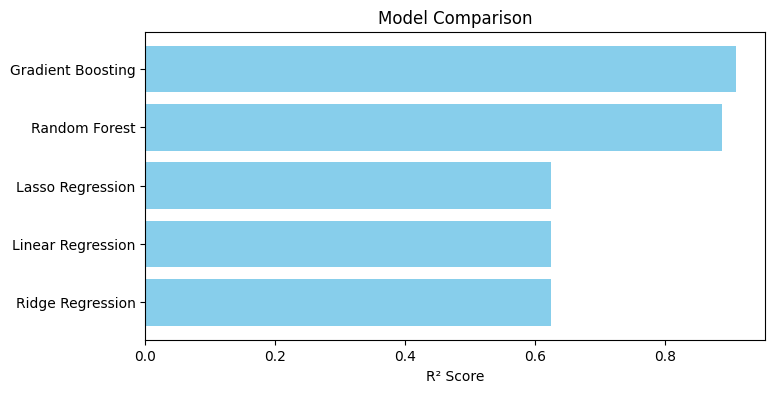

In [50]:
plt.figure(figsize=(8,4))
plt.barh(results_df["Model"], results_df["R2"], color="skyblue")
plt.xlabel("R² Score")
plt.title("Model Comparison")
plt.gca().invert_yaxis()
plt.show()


####Cross-Validation check

In [52]:
from sklearn.model_selection import cross_val_score, KFold

best_model = best_gb  # assume Gradient Boosting performed best
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="r2", n_jobs=-1)

print(f"Cross-validated R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Cross-validated R²: 0.912 ± 0.008


####Save the final model

In [56]:
import os
import joblib

# ✅ Choose a valid folder path for your environment
# For Google Colab:
save_dir = "/content"

# For local Jupyter or VS Code:
# save_dir = "."

# 1️⃣ Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# 2️⃣ Build the complete file path
save_path = os.path.join(save_dir, "final_solar_model.pkl")

# 3️⃣ Save the trained model
joblib.dump(best_model, save_path)

print(f"✅ Model saved successfully at: {save_path}")


✅ Model saved successfully at: /content/final_solar_model.pkl


In [59]:
os.listdir(save_dir)


['.config',
 'solar_model_outputs',
 'final_solar_model.pkl',
 'solarpowergeneration.csv',
 'sample_data']

####Predicted vs Actual plot

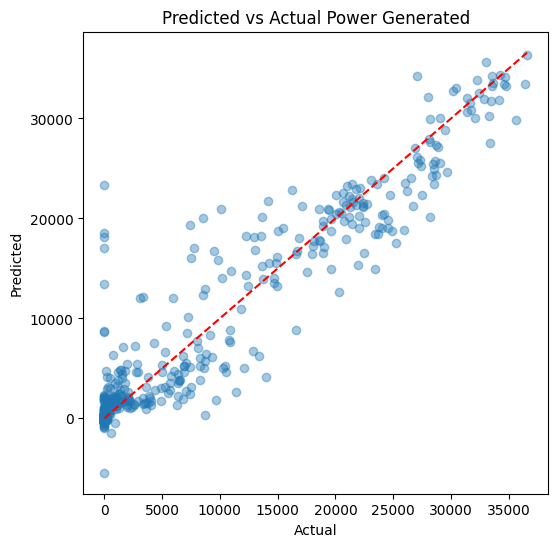

In [62]:
y_pred = best_model.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Power Generated")
plt.show()


####Residual plot

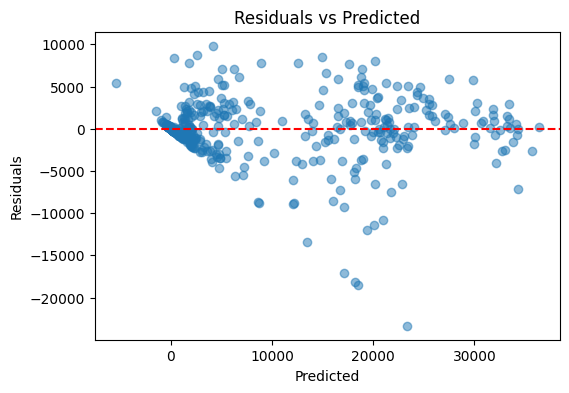

In [63]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


####Feature importance (tree models only)

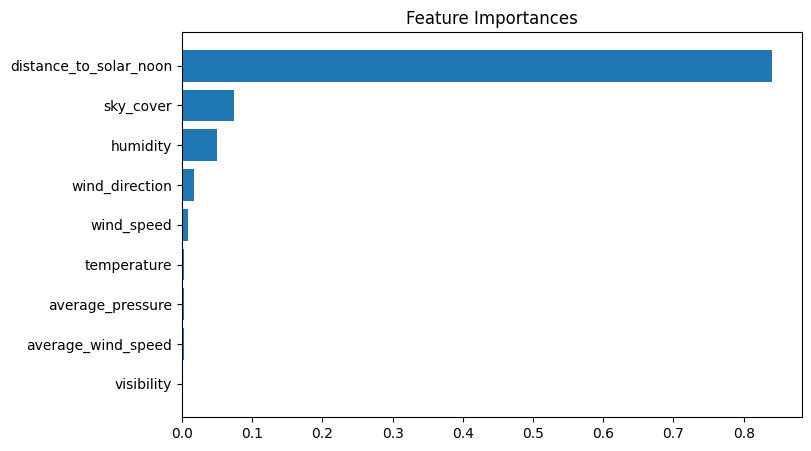

In [64]:
importances = best_model.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.show()


####SHAP explainability

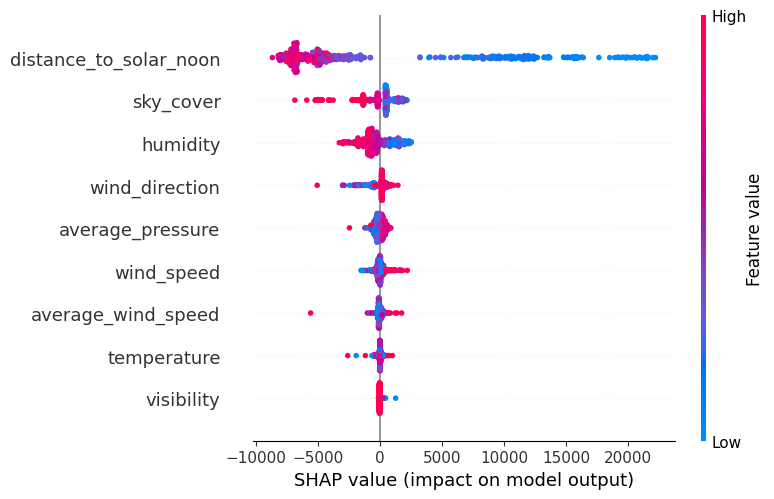

In [65]:
import shap
explainer = shap.TreeExplainer(best_model)
sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)
